In [ ]:
from google.colab import drive
import os
import sys

drive.mount('/content/drive')

!pip install transformers accelerate -q
!pip install torchmetrics -q
!pip install "segmentation-models-pytorch @ git+https://github.com/qubvel/segmentation_models.pytorch" -q
!pip install albumentations -q

# CELDA 1: Configuración

In [ ]:
DRIVE_ROOT = "/content/drive/MyDrive/plant_segmentation"
CKPT_PATH = os.path.join(DRIVE_ROOT, "ckpts_3models_resize")
os.makedirs(CKPT_PATH, exist_ok=True)
DATA_ROOT = DRIVE_ROOT

# Parámetros Globales
DATASET_TYPE = "cwt" # 'cwt' o 'dead'
INVENTARY_NAME = "data_inventary.csv"
IMG_SIZE = 512
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 70
SEED = 42313988

if DATASET_TYPE == 'dead':
    LABEL2ID_DATASET = {'dead': 0, 'dead_cut': 1, 'noise': 2}
    ID2LABEL_MODEL = {0: 'background', 1: 'dead', 2: 'dead_cut'}
else:
    LABEL2ID_DATASET = {'normal': 0, 'normal_cut': 1, 'noise': 2}
    ID2LABEL_MODEL = {0: 'background', 1: 'normal', 2: 'normal_cut'}

LABEL2ID_MODEL = {v: k for k, v in ID2LABEL_MODEL.items()}
NUM_CLASSES = len(ID2LABEL_MODEL)

print(f"✅ Configuración lista para 3 modelos. Dataset: {DATASET_TYPE}. Seed: {SEED}")

✅ Configuración lista para 3 modelos. Dataset: cwt. Seed: 42313988


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from PIL import Image
import pandas as pd
import numpy as np
import re
import random
import cv2
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from torchmetrics import JaccardIndex
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from torch.cuda.amp import GradScaler, autocast

# CELDA 2:  Augmentations y Utils

In [ ]:
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_augs = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
        A.GridDistortion(p=0.5),
    ], p=0.3),

    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),

    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])

val_augs = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])

def clean_mask_prediction(mask_np, min_size=30):
    cleaned_mask = mask_np.copy()
    for class_id in [1, 2]:
        binary_class_mask = (mask_np == class_id).astype(np.uint8)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_class_mask, connectivity=8)
        for i in range(1, num_labels):
            if stats[i, cv2.CC_STAT_AREA] < min_size:
                cleaned_mask[labels == i] = 0
    return cleaned_mask

class JointLoss(nn.Module):
    def __init__(self, dice_weight=0.5, focal_weight=0.5):
        super(JointLoss, self).__init__()
        self.dice_loss = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
        self.focal_loss = smp.losses.FocalLoss(mode='multiclass')
        self.dw = dice_weight
        self.fw = focal_weight

    def forward(self, y_pred, y_true):
        return self.dw * self.dice_loss(y_pred, y_true) + self.fw * self.focal_loss(y_pred, y_true)

/tmp/ipython-input-997242143.py:31: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),


# CELDA 3: Dataset y DataLoaders

In [ ]:
def get_multiclass_target_np(masks, labels, size):
    target_mask = np.zeros(size, dtype=np.uint8)
    for mask_path, label_id in zip(masks, labels):
        if label_id in [0, 1]:
            mask_pil = Image.open(mask_path)
            if mask_pil.size != (size[1], size[0]):
                 mask_pil = mask_pil.resize((size[1], size[0]), resample=Image.NEAREST)

            mask_np = np.array(mask_pil)
            pixels_to_update = mask_np > 0
            target_mask[pixels_to_update] = label_id + 1
    return target_mask

class PlantDataset(Dataset):
    def __init__(self, root, folder, inventary_name, label2id, transform=None):
        self.root = root
        self.folder = folder
        self.transform = transform
        self._label2id = label2id
        self.idx_table = pd.read_csv(os.path.join(self.root, self.folder, inventary_name))
        self.images, self.masks, self.labels = [], [], []

        files_in_folder = sorted(os.listdir(os.path.join(self.root, self.folder, 'original')),
                               key=lambda x: (int(re.findall(r'\d+', x.split('_')[0])[0]),
                                              int(re.findall(r'\d+', x.split('_')[1])[0])))

        for img_name in files_in_folder:
            id_original_img = int(re.findall(r'\d+', img_name.split('_')[0])[0])
            id_after_split = int(re.findall(r'\d+', img_name.split('_')[1])[0])
            mask_idx_row = self.idx_table[(self.idx_table['id orginal img'] == id_original_img) & (self.idx_table['id after split'] == id_after_split)]
            if mask_idx_row.empty: continue

            self.images.append(os.path.join(self.root, self.folder, 'original', img_name))
            mask_idx = mask_idx_row['id']._values[0]
            mask_dir = os.path.join(self.root, self.folder, 'original_labeled', str(mask_idx))

            current_masks, current_labels = [], []
            if os.path.exists(mask_dir):
                get_tag = lambda x: x.split('/')[-1].split('-')[-2]
                for m_name in os.listdir(mask_dir):
                    tag = get_tag(m_name)
                    if tag in self._label2id:
                        current_masks.append(os.path.join(mask_dir, m_name))
                        current_labels.append(self._label2id[tag])
            self.masks.append(current_masks)
            self.labels.append(current_labels)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        image_pil = Image.open(image_path).convert('RGB')
        w, h = image_pil.size
        image_np = np.array(image_pil)

        mask_np = get_multiclass_target_np(self.masks[idx], self.labels[idx], size=(h, w))

        if self.transform:
            augmented = self.transform(image=image_np, mask=mask_np)
            image_np = augmented['image']
            mask_np = augmented['mask']

        return image_np, mask_np.long()

dataset_base = PlantDataset(DATA_ROOT, DATASET_TYPE, INVENTARY_NAME, label2id=LABEL2ID_DATASET, transform=None)
val_pct = 0.15
val_size = int(len(dataset_base) * val_pct)
train_size = len(dataset_base) - val_size

set_seed(SEED)
train_indices, val_indices = random_split(range(len(dataset_base)), [train_size, val_size])

train_ds = PlantDataset(DATA_ROOT, DATASET_TYPE, INVENTARY_NAME, label2id=LABEL2ID_DATASET, transform=train_augs)
val_ds = PlantDataset(DATA_ROOT, DATASET_TYPE, INVENTARY_NAME, label2id=LABEL2ID_DATASET, transform=val_augs)

train_subset = Subset(train_ds, train_indices)
val_subset = Subset(val_ds, val_indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"📊 Dataset Split: Train={len(train_subset)}, Val={len(val_subset)}")

📊 Dataset Split: Train=59, Val=10


# CELDA 4: Definición de los 3 Modelos

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def get_model(model_name):
    if model_name == "unet_resnet":
        print("🏗️ Creando Modelo 1: U-Net (ResNet34)...")
        model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=3,
            classes=NUM_CLASSES,
        )
    elif model_name == "unet_transformer":
        print("🏗️ Creando Modelo 2: U-Net (MiT-B2 Transformer)...")
        model = smp.Unet(
            encoder_name="mit_b2",
            encoder_weights="imagenet",
            in_channels=3,
            classes=NUM_CLASSES,
        )
    elif model_name == "segformer_fpn":
        print("🏗️ Creando Modelo 3: SegFormer (FPN + MiT-B2)...")
        model = smp.FPN(
            encoder_name="mit_b2",
            encoder_weights="imagenet",
            in_channels=3,
            classes=NUM_CLASSES,
        )
    return model.to(device)

# CELDA 5: Función de Entrenamiento

In [ ]:
def train_engine(model, model_alias, train_dl, val_dl, epochs=EPOCHS):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
    loss_fn = JointLoss(dice_weight=0.5, focal_weight=0.5).to(device)
    scaler = GradScaler()
    jaccard = JaccardIndex(task="multiclass", num_classes=NUM_CLASSES, average='macro', ignore_index=0).to(device)

    best_iou = 0.0
    history = {'train_loss': [], 'val_iou_clean': []}

    print(f"\n🚀 Entrenando: {model_alias}...")

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        loop = tqdm(train_dl, desc=f"Ep {epoch+1}/{epochs}", leave=False)

        for xb, yb in loop:
            xb, yb = xb.to(device), yb.to(device)
            with autocast():
                outputs = model(xb)
                loss = loss_fn(outputs, yb)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        scheduler.step()
        avg_train_loss = train_loss / len(train_dl)
        history['train_loss'].append(avg_train_loss)

        model.eval()
        iou_clean_accum = 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                preds = torch.argmax(outputs, dim=1)

                preds_clean = preds.clone()
                for i in range(preds.shape[0]):
                    mask_cpu = preds[i].cpu().numpy().astype(np.uint8)
                    mask_clean = clean_mask_prediction(mask_cpu, min_size=30)
                    preds_clean[i] = torch.from_numpy(mask_clean).to(device)

                iou_clean_accum += jaccard(preds_clean, yb).item()

        avg_iou_clean = iou_clean_accum / len(val_dl)
        history['val_iou_clean'].append(avg_iou_clean)

        print(f"   Loss: {avg_train_loss:.4f} | mIoU (Clean): {avg_iou_clean:.4f}")

        if avg_iou_clean > best_iou:
            best_iou = avg_iou_clean
            torch.save(model.state_dict(), os.path.join(CKPT_PATH, f"best_{model_alias}_{DATASET_TYPE}.pth"))
            print(f"   💾 Guardado ({best_iou:.4f})")

    return history

# CELDA 6: Ejecución de los 3 Modelos

In [ ]:
# SegFormer (FPN MiT)
model_3 = get_model("segformer_fpn")
hist_3 = train_engine(model_3, "segformer_fpn", train_loader, val_loader)

🏗️ Creando Modelo 3: SegFormer (FPN + MiT-B2)...

🚀 Entrenando: segformer_fpn...


/tmp/ipython-input-1441790333.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Ep 1/70:   0%|          | 0/8 [00:00<?, ?it/s]

/tmp/ipython-input-1441790333.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Loss: 1.6627 | mIoU (Clean): 0.0704
   💾 Guardado (0.0704)


...

   Loss: 0.1017 | mIoU (Clean): 0.5998


Ep 69/70:   0%|          | 0/8 [00:00<?, ?it/s]

   Loss: 0.0988 | mIoU (Clean): 0.5989


Ep 70/70:   0%|          | 0/8 [00:00<?, ?it/s]

   Loss: 0.0976 | mIoU (Clean): 0.5993


In [ ]:
# U-Net (ResNet)
model_1 = get_model("unet_resnet")
hist_1 = train_engine(model_1, "unet_resnet", train_loader, val_loader)

🏗️ Creando Modelo 1: U-Net (ResNet34)...

🚀 Entrenando: unet_resnet...


/tmp/ipython-input-1441790333.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Ep 1/70:   0%|          | 0/8 [00:00<?, ?it/s]

/tmp/ipython-input-1441790333.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Loss: 0.8059 | mIoU (Clean): 0.4211
   💾 Guardado (0.4211)


...

   Loss: 0.2439 | mIoU (Clean): 0.5541


Ep 69/70:   0%|          | 0/8 [00:00<?, ?it/s]

   Loss: 0.2454 | mIoU (Clean): 0.5727


Ep 70/70:   0%|          | 0/8 [00:00<?, ?it/s]

   Loss: 0.2489 | mIoU (Clean): 0.5719


In [ ]:
# U-Net (Transformer MiT)
model_2 = get_model("unet_transformer")
hist_2 = train_engine(model_2, "unet_transformer", train_loader, val_loader)

🏗️ Creando Modelo 2: U-Net (MiT-B2 Transformer)...

🚀 Entrenando: unet_transformer...


/tmp/ipython-input-1441790333.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Ep 1/70:   0%|          | 0/8 [00:00<?, ?it/s]

/tmp/ipython-input-1441790333.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Loss: 0.7874 | mIoU (Clean): 0.2637
   💾 Guardado (0.2637)


...

   Loss: 0.1937 | mIoU (Clean): 0.5566


Ep 69/70:   0%|          | 0/8 [00:00<?, ?it/s]

   Loss: 0.2075 | mIoU (Clean): 0.5584


Ep 70/70:   0%|          | 0/8 [00:00<?, ?it/s]

   Loss: 0.2112 | mIoU (Clean): 0.5610


# CELDA 7: Estadísticas Finales y Gráficos


📊 Generando estadísticas finales...
🏗️ Creando Modelo 1: U-Net (ResNet34)...


Stats:   0%|          | 0/2 [00:00<?, ?it/s]

🏗️ Creando Modelo 2: U-Net (MiT-B2 Transformer)...


Stats:   0%|          | 0/2 [00:00<?, ?it/s]

🏗️ Creando Modelo 3: SegFormer (FPN + MiT-B2)...


Stats:   0%|          | 0/2 [00:00<?, ?it/s]


📝 Tabla Comparativa:


,Model,Mean mIoU,Std Dev,Paper Format
0,U-Net (ResNet34),0.755999,0.178592,0.756 ± 0.179
1,U-Net (Transformer),0.672770,0.220955,0.673 ± 0.221
2,SegFormer (FPN),0.636629,0.260644,0.637 ± 0.261


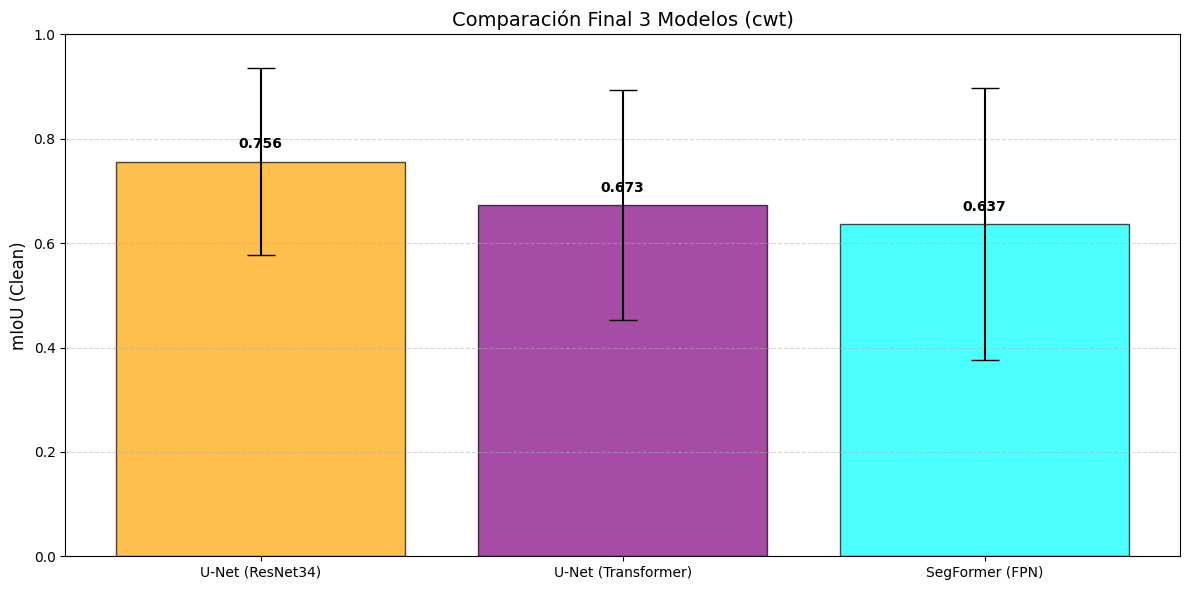

In [ ]:
def get_detailed_stats(model, loader, device, num_classes):
    model.eval()
    iou_per_image = []
    metric = JaccardIndex(task="multiclass", num_classes=num_classes, average='macro', ignore_index=0).to(device)

    with torch.no_grad():
        for xb, yb in tqdm(loader, desc="Stats", leave=False):
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds = torch.argmax(out, dim=1)

            preds_clean = preds.clone()
            for i in range(preds.shape[0]):
                mask_cpu = preds[i].cpu().numpy().astype(np.uint8)
                mask_clean = clean_mask_prediction(mask_cpu, min_size=30)
                preds_clean[i] = torch.from_numpy(mask_clean).to(device)

                single_iou = metric(preds_clean[i].unsqueeze(0), yb[i].unsqueeze(0))
                iou_per_image.append(single_iou.item())
    return np.array(iou_per_image)

print("\n📊 Generando estadísticas finales...")

# Cargar pesos
m1 = get_model("unet_resnet")
m1.load_state_dict(torch.load(os.path.join(CKPT_PATH, f"best_unet_resnet_{DATASET_TYPE}.pth")))
ious_1 = get_detailed_stats(m1, val_loader, device, NUM_CLASSES)

m2 = get_model("unet_transformer")
m2.load_state_dict(torch.load(os.path.join(CKPT_PATH, f"best_unet_transformer_{DATASET_TYPE}.pth")))
ious_2 = get_detailed_stats(m2, val_loader, device, NUM_CLASSES)

m3 = get_model("segformer_fpn")
m3.load_state_dict(torch.load(os.path.join(CKPT_PATH, f"best_segformer_fpn_{DATASET_TYPE}.pth")))
ious_3 = get_detailed_stats(m3, val_loader, device, NUM_CLASSES)

# Tabla
stats = {
    "Model": ["U-Net (ResNet34)", "U-Net (Transformer)", "SegFormer (FPN)"],
    "Mean mIoU": [np.mean(ious_1), np.mean(ious_2), np.mean(ious_3)],
    "Std Dev": [np.std(ious_1), np.std(ious_2), np.std(ious_3)]
}
df_stats = pd.DataFrame(stats)
df_stats["Paper Format"] = df_stats.apply(lambda x: f"{x['Mean mIoU']:.3f} ± {x['Std Dev']:.3f}", axis=1)

print("\n📝 Tabla Comparativa:")
display(df_stats)
df_stats.to_csv(os.path.join(CKPT_PATH, f"final_stats_3models_{DATASET_TYPE}.csv"), index=False)

# Gráfico
plt.figure(figsize=(12, 6))
colors = ['orange', 'purple', 'cyan']
bars = plt.bar(df_stats["Model"], df_stats["Mean mIoU"], yerr=df_stats["Std Dev"], capsize=10, color=colors, alpha=0.7, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.3f}", ha='center', va='bottom', fontweight='bold')

plt.title(f"Comparación Final 3 Modelos ({DATASET_TYPE})", fontsize=14)
plt.ylabel("mIoU (Clean)", fontsize=12)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_PATH, f"barplot_3models_{DATASET_TYPE}.png"), dpi=300)
plt.show()

# CELDA 8: Gráficos de Entrenamiento (Individuales y Comparativos)


📈 Generando Gráficos de Entrenamiento...


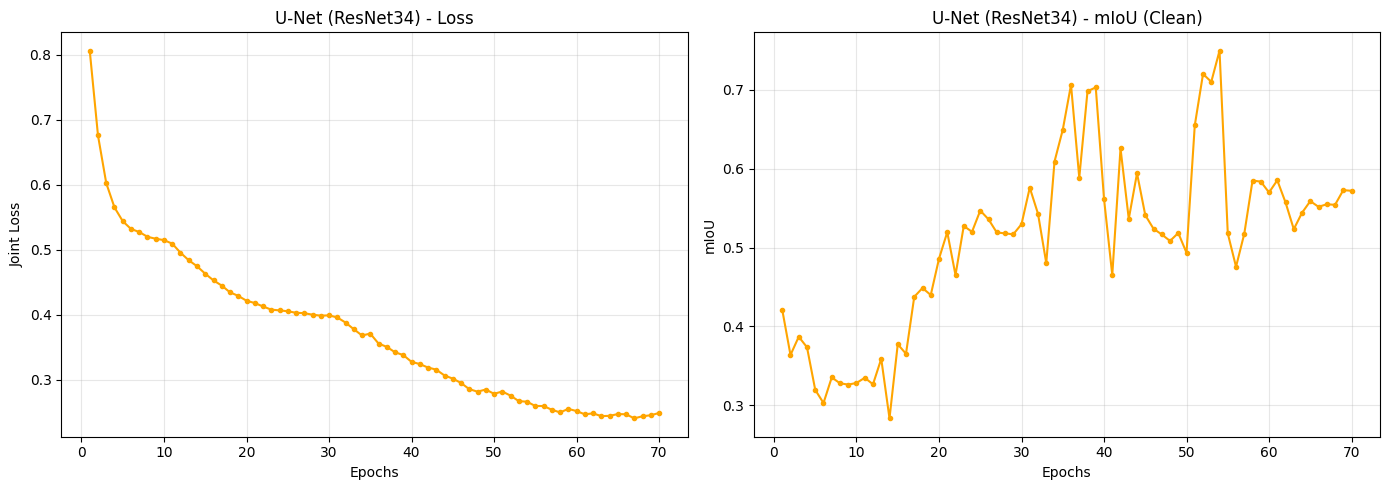

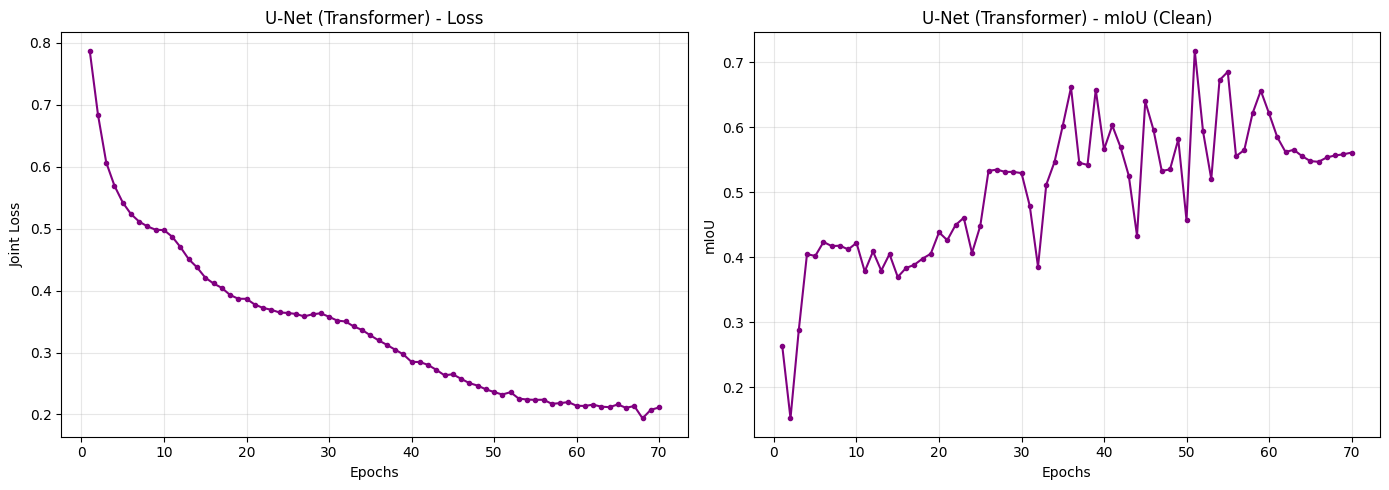

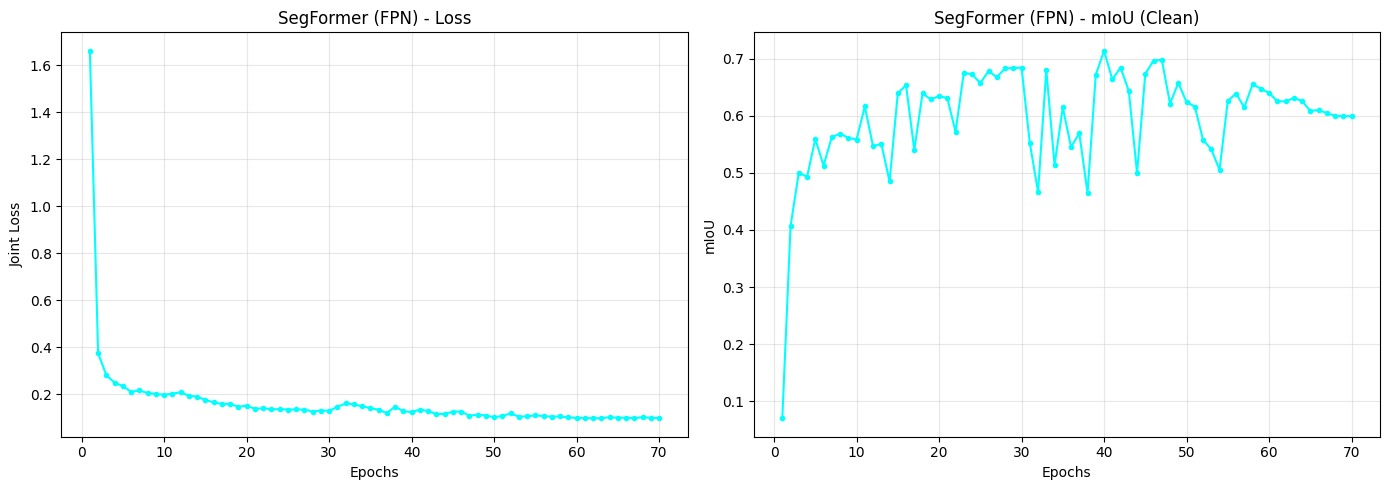

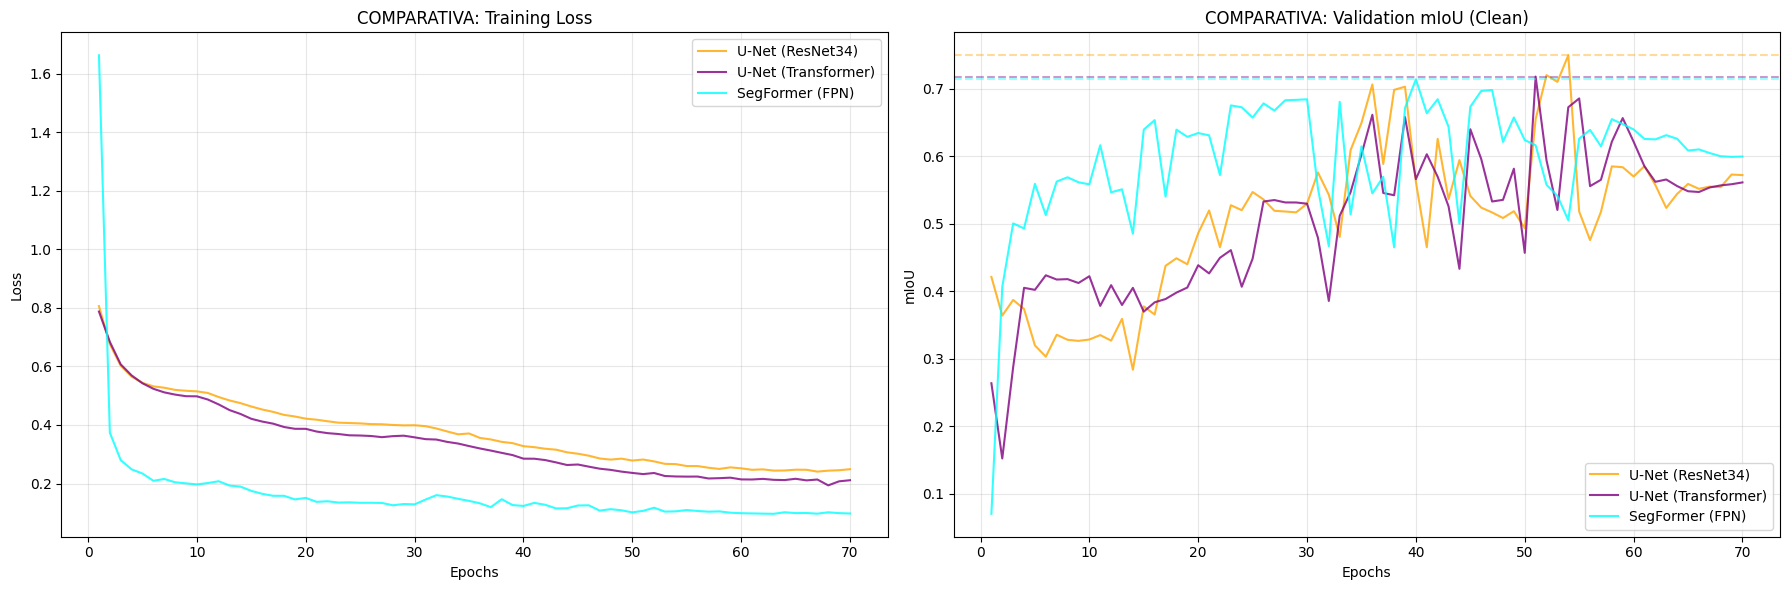

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

colors = {'unet_resnet': 'orange', 'unet_transformer': 'purple', 'segformer_fpn': 'cyan'}
labels = {'unet_resnet': 'U-Net (ResNet34)', 'unet_transformer': 'U-Net (Transformer)', 'segformer_fpn': 'SegFormer (FPN)'}

def plot_single_model(history, model_key):
    """Grafica Loss y mIoU para un solo modelo"""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history['train_loss'], 'o-', color=colors[model_key], label='Train Loss', markersize=3)
    ax1.set_title(f"{labels[model_key]} - Loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Joint Loss")
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['val_iou_clean'], 'o-', color=colors[model_key], label='Val mIoU (Clean)', markersize=3)
    ax2.set_title(f"{labels[model_key]} - mIoU (Clean)")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("mIoU")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_comparison(h1, h2, h3):
    """Grafica las curvas de los 3 modelos superpuestas"""
    epochs = range(1, len(h1['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    ax1.plot(epochs, h1['train_loss'], label=labels['unet_resnet'], color=colors['unet_resnet'], alpha=0.8)
    ax1.plot(epochs, h2['train_loss'], label=labels['unet_transformer'], color=colors['unet_transformer'], alpha=0.8)
    ax1.plot(epochs, h3['train_loss'], label=labels['segformer_fpn'], color=colors['segformer_fpn'], alpha=0.8)
    ax1.set_title("COMPARATIVA: Training Loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, h1['val_iou_clean'], label=labels['unet_resnet'], color=colors['unet_resnet'], alpha=0.8)
    ax2.plot(epochs, h2['val_iou_clean'], label=labels['unet_transformer'], color=colors['unet_transformer'], alpha=0.8)
    ax2.plot(epochs, h3['val_iou_clean'], label=labels['segformer_fpn'], color=colors['segformer_fpn'], alpha=0.8)

    max_1 = max(h1['val_iou_clean'])
    max_2 = max(h2['val_iou_clean'])
    max_3 = max(h3['val_iou_clean'])

    ax2.axhline(max_1, color=colors['unet_resnet'], linestyle='--', alpha=0.4)
    ax2.axhline(max_2, color=colors['unet_transformer'], linestyle='--', alpha=0.4)
    ax2.axhline(max_3, color=colors['segformer_fpn'], linestyle='--', alpha=0.4)

    ax2.set_title("COMPARATIVA: Validation mIoU (Clean)")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("mIoU")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("📈 Generando Gráficos de Entrenamiento...")

# Gráficos Individuales
plot_single_model(hist_1, 'unet_resnet')
plot_single_model(hist_2, 'unet_transformer')
plot_single_model(hist_3, 'segformer_fpn')

# Gráfico Comparativo Final
plot_comparison(hist_1, hist_2, hist_3)

# CELDA 9: Visualización Detallada y Tabla de Resultados

/tmp/ipython-input-3377718863.py:6: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  A.Normalize(mean=[-m/s for m, s in zip(mean, std)], std=[1/s for s in std], max_pixel_value=1.0, always_apply=True),


📥 Cargando modelos óptimos...
🏗️ Creando Modelo 1: U-Net (ResNet34)...
🏗️ Creando Modelo 2: U-Net (MiT-B2 Transformer)...
🏗️ Creando Modelo 3: SegFormer (FPN + MiT-B2)...
🖼️ Generando visualizaciones para 10 imágenes...


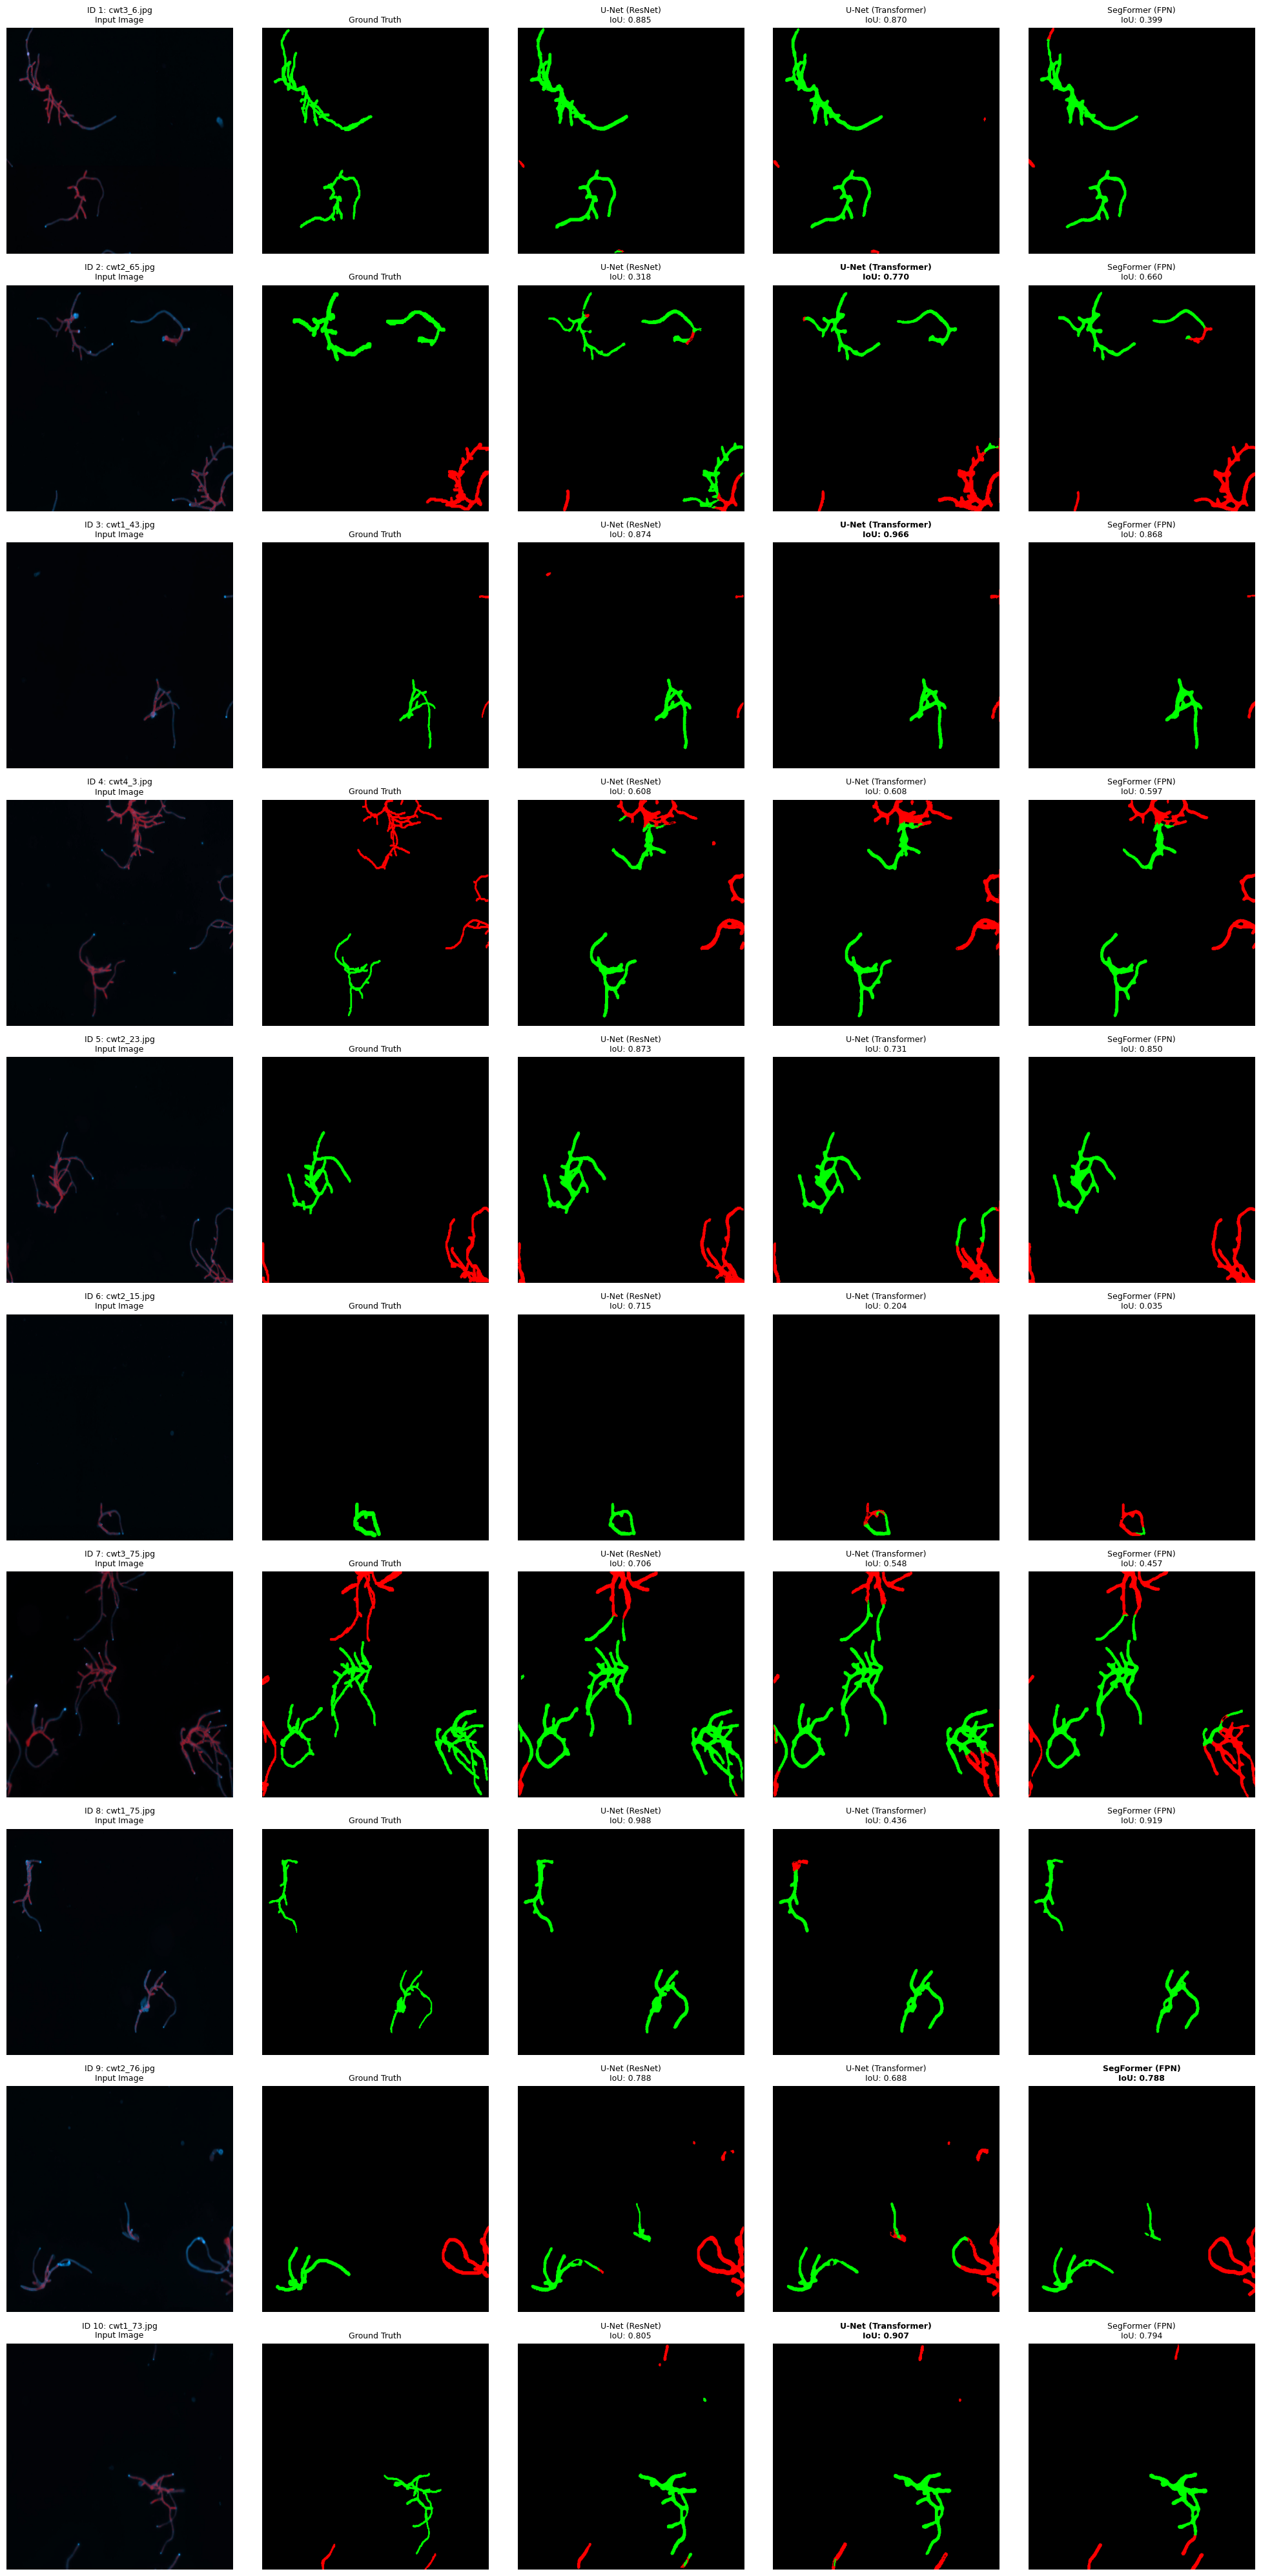


📊 TABLA DE RESULTADOS POR IMAGEN:


,ID,Filename,IoU U-Net (ResNet),IoU U-Net (Transf),IoU SegFormer (FPN),Winner
0,1,cwt3_6.jpg,0.885167,0.869908,0.399134,U-Net (ResNet)
1,2,cwt2_65.jpg,0.318202,0.769663,0.660235,U-Net (Transf)
2,3,cwt1_43.jpg,0.874147,0.965623,0.868231,U-Net (Transf)
3,4,cwt4_3.jpg,0.608235,0.607683,0.596582,U-Net (ResNet)
4,5,cwt2_23.jpg,0.872527,0.731287,0.849776,U-Net (ResNet)
5,6,cwt2_15.jpg,0.714882,0.203916,0.034987,U-Net (ResNet)
6,7,cwt3_75.jpg,0.706500,0.548380,0.456688,U-Net (ResNet)
7,8,cwt1_75.jpg,0.987697,0.435812,0.919230,U-Net (ResNet)
8,9,cwt2_76.jpg,0.787595,0.688479,0.787701,SegFormer
9,10,cwt1_73.jpg,0.805036,0.906953,0.793730,U-Net (Transf)


✅ Resultados detallados guardados en: /content/drive/MyDrive/plant_segmentation/ckpts_3models_resize/detailed_results_by_image_cwt.csv
✅ Imagen comparativa guardada en: /content/drive/MyDrive/plant_segmentation/ckpts_3models_resize/visual_comparison_cwt.png


In [ ]:
# Configuración de Visualización
inv_normalize = A.Compose([
    A.Normalize(mean=[-m/s for m, s in zip(mean, std)], std=[1/s for s in std], max_pixel_value=1.0, always_apply=True),
])

# Mapa de colores para máscaras (0=Negro, 1=Verde, 2=Rojo/Magenta)
# Ajusta estos colores si prefieres otros.
# Formato: [R, G, B]
palette = np.array([
    [0, 0, 0],       # 0: Background (Negro)
    [0, 255, 0],     # 1: Normal/Dead (Verde)
    [255, 0, 0]      # 2: Cut (Rojo)
], dtype=np.uint8)

def mask_to_rgb(mask_tensor):
    """Convierte tensor (H,W) de clases a numpy (H,W,3) RGB"""
    mask_np = mask_tensor.cpu().numpy().astype(np.uint8)
    return palette[mask_np]

def predict_and_clean(model, xb):
    """Realiza inferencia y limpieza"""
    model.eval()
    with torch.no_grad():
        out = model(xb)
        pred = torch.argmax(out, dim=1)[0]
        mask_cpu = pred.cpu().numpy().astype(np.uint8)
        mask_clean = clean_mask_prediction(mask_cpu, min_size=30)
        return torch.from_numpy(mask_clean).to(device)

# Cargar Mejores Modelos
print("📥 Cargando modelos óptimos...")
model_1 = get_model("unet_resnet")
model_1.load_state_dict(torch.load(os.path.join(CKPT_PATH, f"best_unet_resnet_{DATASET_TYPE}.pth")))

model_2 = get_model("unet_transformer")
model_2.load_state_dict(torch.load(os.path.join(CKPT_PATH, f"best_unet_transformer_{DATASET_TYPE}.pth")))

model_3 = get_model("segformer_fpn")
model_3.load_state_dict(torch.load(os.path.join(CKPT_PATH, f"best_segformer_fpn_{DATASET_TYPE}.pth")))

val_loader_single = DataLoader(val_subset, batch_size=1, shuffle=False)

# Loop de Evaluación y Plotting
results_data = []
metric = JaccardIndex(task="multiclass", num_classes=NUM_CLASSES, average='macro', ignore_index=0).to(device)

print(f"🖼️ Generando visualizaciones para {len(val_subset)} imágenes...")

LIMIT_IMAGES = 20

num_imgs_to_show = min(len(val_subset), LIMIT_IMAGES)
fig, axes = plt.subplots(num_imgs_to_show, 5, figsize=(20, 4 * num_imgs_to_show))

for idx, (xb, yb) in enumerate(val_loader_single):
    if idx >= num_imgs_to_show: break

    xb, yb = xb.to(device), yb.to(device)

    original_idx = val_indices[idx]
    filename = os.path.basename(dataset_base.images[original_idx])

    p1 = predict_and_clean(model_1, xb)
    p2 = predict_and_clean(model_2, xb)
    p3 = predict_and_clean(model_3, xb)

    iou_1 = metric(p1.unsqueeze(0), yb).item()
    iou_2 = metric(p2.unsqueeze(0), yb).item()
    iou_3 = metric(p3.unsqueeze(0), yb).item()

    # Guardar datos
    results_data.append({
        "ID": idx + 1,
        "Filename": filename,
        "IoU U-Net (ResNet)": iou_1,
        "IoU U-Net (Transf)": iou_2,
        "IoU SegFormer (FPN)": iou_3,
        "Winner": ["U-Net (ResNet)", "U-Net (Transf)", "SegFormer"][np.argmax([iou_1, iou_2, iou_3])]
    })

    # PLOTTING
    ax = axes[idx] if num_imgs_to_show > 1 else axes

    img_viz = inv_normalize(image=xb[0].permute(1,2,0).cpu().numpy())['image']
    ax[0].imshow(img_viz)
    ax[0].set_title(f"ID {idx+1}: {filename}\nInput Image", fontsize=9)
    ax[0].axis('off')

    ax[1].imshow(mask_to_rgb(yb[0]))
    ax[1].set_title("Ground Truth", fontsize=9)
    ax[1].axis('off')

    ax[2].imshow(mask_to_rgb(p1))
    ax[2].set_title(f"U-Net (ResNet)\nIoU: {iou_1:.3f}", fontsize=9)
    ax[2].axis('off')

    ax[3].imshow(mask_to_rgb(p2))
    ax[3].set_title(f"U-Net (Transformer)\nIoU: {iou_2:.3f}", fontsize=9, fontweight='bold' if iou_2 >= max(iou_1, iou_3) else 'normal')
    ax[3].axis('off')

    ax[4].imshow(mask_to_rgb(p3))
    ax[4].set_title(f"SegFormer (FPN)\nIoU: {iou_3:.3f}", fontsize=9, fontweight='bold' if iou_3 >= max(iou_1, iou_2) else 'normal')
    ax[4].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CKPT_PATH, f"visual_comparison_{DATASET_TYPE}.png"), dpi=150)
plt.show()

# 5. Generar y Guardar Tabla
df_res = pd.DataFrame(results_data)
csv_path = os.path.join(CKPT_PATH, f"detailed_results_by_image_{DATASET_TYPE}.csv")
df_res.to_csv(csv_path, index=False)

print("\n📊 TABLA DE RESULTADOS POR IMAGEN:")
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

display(df_res.style.apply(highlight_max, subset=["IoU U-Net (ResNet)", "IoU U-Net (Transf)", "IoU SegFormer (FPN)"], axis=1))

print(f"✅ Resultados detallados guardados en: {csv_path}")
print(f"✅ Imagen comparativa guardada en: {os.path.join(CKPT_PATH, f'visual_comparison_{DATASET_TYPE}.png')}")